## EDA numerical features

In this notebook I will perform EDA on numerical features.

#### Columns:
- `tenure`
- `monthly_charges`
- `total_charges`

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from telco_churn.config import (
    NUMERICAL_COLUMNS,
    TARGET_COLUMN,
)
from telco_churn.paths import (
    TELCO_CUSTOMERS_TRAIN_PATH,
    EDA_NUMERICAL_DIR,
)
from telco_churn.plots import save_plot

## Load training data and prepare numerical features for EDA

In [2]:
df_train = pd.read_csv(TELCO_CUSTOMERS_TRAIN_PATH)

df_numerical = df_train[list(NUMERICAL_COLUMNS)].copy()
df_numerical['churn'] = df_train[TARGET_COLUMN]

In [3]:
df_numerical.head()

,tenure,monthly_charges,total_charges,churn
0,8,20.20,140.95,No
1,17,25.65,440.20,No
2,13,40.55,590.35,No
3,26,73.50,1905.70,No
4,1,44.55,44.55,No


## Column: `Tenure`

In [4]:
# Creating a table with statistics.
tenure_stats = df_numerical.describe()['tenure']
tenure_stats['median'] = df_numerical['tenure'].median()
tenure_stats['iqr'] = tenure_stats['75%'] - tenure_stats['25%']
tenure_stats['nunique'] = df_numerical['tenure'].nunique()

tenure_stats

count      5634.000000
mean         32.482783
std          24.548061
min           0.000000
25%           9.000000
50%          29.000000
75%          55.000000
max          72.000000
median       29.000000
iqr          46.000000
nunique      73.000000
Name: tenure, dtype: float64

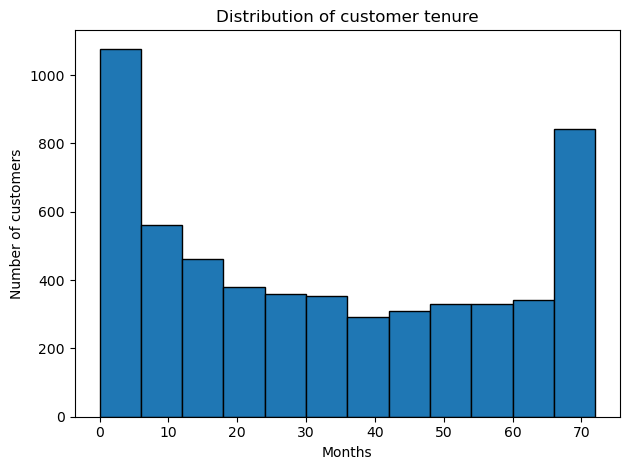


Skewness: 0.24


In [5]:
# Analyzing histogram to understand distribution
tenure_ax = df_numerical['tenure'].plot(
    kind='hist',
    bins=12,
    edgecolor='black',
    linewidth=1,
)

plt.grid(False)
plt.ylabel('Number of customers')
plt.xlabel('Months')
plt.title('Distribution of customer tenure')
plt.tight_layout()
save_plot(
    path=EDA_NUMERICAL_DIR,
    file_name='tenure_histogram',
)
plt.show()

# Calculating skewness to assess asymmetry
tenure_skew = df_numerical['tenure'].skew()

print(f'\nSkewness: {tenure_skew.round(2)}')

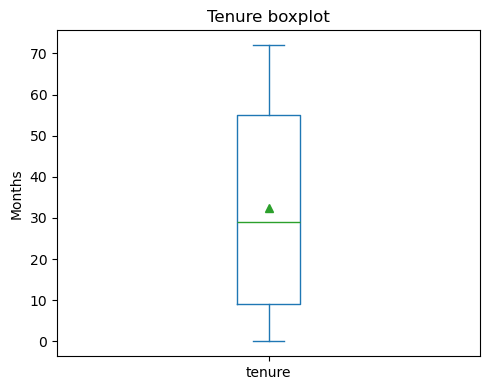

In [6]:
# Visualizing tenure spread and potential outliers
tenure_boxplot = df_numerical['tenure'].plot(
    kind='box',
    figsize=(5,4),
    showmeans=True,
)

plt.title('Tenure boxplot')
plt.ylabel('Months')
plt.tight_layout()
save_plot(
    path=EDA_NUMERICAL_DIR,
    file_name='tenure_boxplot',
)
plt.show()

In [9]:
# Detecting potential outliers using the IQR method
iqr_outliers_lower = tenure_stats['25%'] - 1.5 * tenure_stats['iqr']
iqr_outliers_upper = tenure_stats['75%'] + 1.5 * tenure_stats['iqr']

outliers_lower = (df_numerical['tenure'] < iqr_outliers_lower).sum()
outliers_upper = (df_numerical['tenure'] > iqr_outliers_upper).sum()

print(
    f'Number of outliers on the left side: {outliers_lower}.\n'
    f'Number of outliers on the right side: {outliers_upper}.'
)

Number of outliers on the left side: 0.
Number of outliers on the right side: 0.


In [10]:
# Comparing tenure statistics between churn groups
tenure_by_churn_stats = (
    df_numerical.groupby('churn')['tenure']
        .agg(
            count='count',
            mean='mean',
            median='median',
            q1=lambda x: x.quantile(0.25),
            q3=lambda x: x.quantile(0.75),
        )
        .round(2)
)

tenure_by_churn_stats

,count,mean,median,q1,q3
churn,,,,,
No,4139,37.67,38.0,15.0,61.0
Yes,1495,18.12,10.0,2.0,29.0


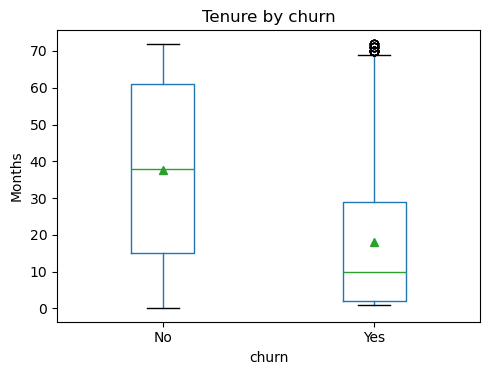

In [13]:
# Visualizing tenure distribution by churn status
tenure_by_churn_boxplot = df_numerical.boxplot(
    column='tenure',
    by='churn',
    figsize=(5,4),
    widths=0.3,
    showmeans=True,
    grid=False,
)

fig = tenure_by_churn_boxplot.get_figure()
fig.suptitle(None)
plt.title('Tenure by churn')
plt.ylabel('Months')
plt.tight_layout()
save_plot(
    path=EDA_NUMERICAL_DIR,
    file_name='tenure_by_churn_boxplot',
)
plt.show()

In [22]:
# Calculate churn rate by tenure bins to identify customer segments with the highest churn rate.
# Each bin represents a 6-month period.
bins = [0, 6, 12, 18, 24, 30, 36, 42, 48, 54, 60, 66, 73]
churn_map = {
    'Yes': 1,
    'No': 0,
}

tenure_churn = df_numerical[['tenure', 'churn']].copy()
tenure_churn['churn'] = tenure_churn['churn'].map(churn_map)
tenure_churn['bins'] = pd.cut(
    tenure_churn['tenure'],
    bins=bins,
    right=False,
)

churn_rate_baseline = tenure_churn['churn'].mean() * 100

tenure_churn_rate = tenure_churn.groupby('bins', observed=True)['churn'].agg(
    customers='count',
    churn_rate='mean',
).reset_index()
tenure_churn_rate['churn_rate'] = (tenure_churn_rate['churn_rate'] * 100).round(2)
tenure_churn_rate['diff_from_churn_rate_baseline'] = (
    tenure_churn_rate['churn_rate']
    - churn_rate_baseline
).round(2)

tenure_churn_rate

,bins,customers,churn_rate,diff_from_churn_rate_baseline
0,"[0, 6)",1077,55.06,28.52
1,"[6, 12)",562,37.19,10.65
2,"[12, 18)",461,32.32,5.78
3,"[18, 24)",379,24.27,-2.27
4,"[24, 30)",358,23.46,-3.08
5,"[30, 36)",353,19.83,-6.71
6,"[36, 42)",292,19.86,-6.68
7,"[42, 48)",310,18.39,-8.15
8,"[48, 54)",329,16.11,-10.43
9,"[54, 60)",330,14.24,-12.30


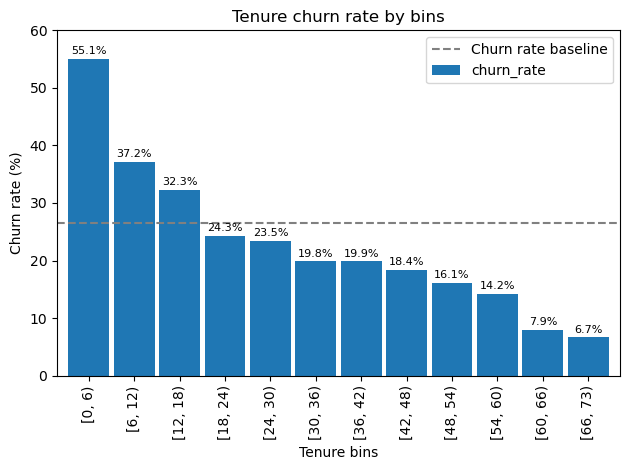

In [24]:
# Visualizing churn rate across tenure bins to identify high-risk segments and overall trend
tenure_churn_rate_ax = tenure_churn_rate.plot(
    kind='bar',
    x='bins',
    y='churn_rate',
    width=0.9,
)

tenure_churn_rate_ax.bar_label(
    tenure_churn_rate_ax.containers[0],
    fmt='%.1f%%',
    padding=2,
    fontsize=8,
)

tenure_churn_rate_ax.axhline(
    y=churn_rate_baseline,
    color='grey',
    linestyle='--',
    label='Churn rate baseline'
)

plt.title('Tenure churn rate by bins')
plt.xlabel('Tenure bins')
plt.ylabel('Churn rate (%)')
plt.legend()
plt.ylim(0, 60)
plt.tight_layout()
save_plot(
    path=EDA_NUMERICAL_DIR,
    file_name='tenure_churn_rate_by_bins',
)
plt.show()

### Summary

Tenure ranges from 0 to 72 months, with a mean of 32.5 and a median of 29 months. The distribution is widely spread and slightly right-skewed, with noticeable concentrations among very new and very long-term customers. No potential outliers were detected using the IQR method.

Customers who churned have clearly lower tenure than non-churners. Their median tenure is 10 months compared with 38 months for non-churners, and their interquartile range is shifted toward lower values.

Churn rate is above the overall baseline in the first three tenure bins and decreases as tenure increases. This suggests that customers in the early stage of their relationship with the company represent a higher-risk segment and may be especially important for retention analysis.